<a href="https://colab.research.google.com/github/Hunny2007/Project/blob/main/Car_prediction_using_ML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Importing the libraries**

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load the data

In [36]:
data=pd.read_csv('/content/Car details v3 (1).csv')

In [37]:
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.7 kmpl,1497 CC,78 bhp,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)",5.0


In [38]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8128 entries, 0 to 8127
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           8128 non-null   object 
 1   year           8128 non-null   int64  
 2   selling_price  8128 non-null   int64  
 3   km_driven      8128 non-null   int64  
 4   fuel           8128 non-null   object 
 5   seller_type    8128 non-null   object 
 6   transmission   8128 non-null   object 
 7   owner          8128 non-null   object 
 8   mileage        7907 non-null   object 
 9   engine         7907 non-null   object 
 10  max_power      7913 non-null   object 
 11  torque         7906 non-null   object 
 12  seats          7907 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 825.6+ KB


**Preprocessing**

In [39]:
data.isnull().sum()

,0
name,0
year,0
selling_price,0
km_driven,0
fuel,0
seller_type,0
transmission,0
owner,0
mileage,221
engine,221


In [40]:
data=data.dropna(axis=0)

In [41]:
def convertToNumber(s:str):
  d=""
  for i in list(s):
    if (i.isdigit() or i=='.'):
      d+=i
  return eval(d)

In [42]:
data['mileage']=data['mileage'].apply(convertToNumber)
data['engine']=data['engine'].apply(convertToNumber)
data['max_power']=data['max_power'].apply(convertToNumber)


In [43]:
data.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque,seats
0,Maruti Swift Dzire VDI,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248,74.00,190Nm@ 2000rpm,5.0
1,Skoda Rapid 1.5 TDI Ambition,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498,103.52,250Nm@ 1500-2500rpm,5.0
2,Honda City 2017-2020 EXi,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497,78.00,"12.7@ 2,700(kgm@ rpm)",5.0
3,Hyundai i20 Sportz Diesel,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396,90.00,22.4 kgm at 1750-2750rpm,5.0
4,Maruti Swift VXI BSIII,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298,88.20,"11.5@ 4,500(kgm@ rpm)",5.0


In [44]:
data=data.drop(['torque','name'],axis=1)
data.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,2014,450000,145500,Diesel,Individual,Manual,First Owner,23.40,1248,74.00,5.0
1,2014,370000,120000,Diesel,Individual,Manual,Second Owner,21.14,1498,103.52,5.0
2,2006,158000,140000,Petrol,Individual,Manual,Third Owner,17.70,1497,78.00,5.0
3,2010,225000,127000,Diesel,Individual,Manual,First Owner,23.00,1396,90.00,5.0
4,2007,130000,120000,Petrol,Individual,Manual,First Owner,16.10,1298,88.20,5.0


In [45]:
data.fuel.unique()

array(['Diesel', 'Petrol', 'LPG', 'CNG'], dtype=object)

In [46]:
data.owner.unique()

array(['First Owner', 'Second Owner', 'Third Owner',
       'Fourth & Above Owner', 'Test Drive Car'], dtype=object)

In [47]:
from sklearn import preprocessing

label_encoder=preprocessing.LabelEncoder()
data['fuel']=label_encoder.fit_transform(data['fuel'])
data['owner']=label_encoder.fit_transform(data['owner'])
data['transmission']=label_encoder.fit_transform(data['transmission'])
data['seller_type']=label_encoder.fit_transform(data['seller_type'])

In [49]:
data.head(10)

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,mileage,engine,max_power,seats
0,2014,450000,145500,1,1,1,0,23.40,1248,74.00,5.0
1,2014,370000,120000,1,1,1,2,21.14,1498,103.52,5.0
2,2006,158000,140000,3,1,1,4,17.70,1497,78.00,5.0
3,2010,225000,127000,1,1,1,0,23.00,1396,90.00,5.0
4,2007,130000,120000,3,1,1,0,16.10,1298,88.20,5.0
5,2017,440000,45000,3,1,1,0,20.14,1197,81.86,5.0
6,2007,96000,175000,2,1,1,0,17.30,1061,57.50,5.0
7,2001,45000,5000,3,1,1,2,16.10,796,37.00,4.0
8,2011,350000,90000,1,1,1,0,23.59,1364,67.10,5.0
9,2013,200000,169000,1,1,1,0,20.00,1399,68.10,5.0


**Scaling**

In [53]:
from sklearn.preprocessing import MinMaxScaler

mmScaler=MinMaxScaler()
mmScaler_y=MinMaxScaler()

x=data.drop(columns=['selling_price']).values
y=data[['selling_price']].values

In [54]:
print(data.shape)
print(x.shape)
print(y.shape)

(7906, 11)
(7906, 10)
(7906, 1)


In [55]:
x=mmScaler.fit_transform(x)
y=mmScaler_y.fit_transform(y)

**EDA(exploratory data Analysis)**

In [59]:
import plotly.graph_objects as go
correlation_matrix=data.corr()

corr=go.Heatmap(
    z = correlation_matrix.values,
    x = correlation_matrix.columns,
    y = correlation_matrix.columns,
    colorscale='RdYlBu',
    colorbar=dict(title='Correlation')
)


layout=go.Layout(
    title='Heatmap of Correlation',
    xaxis=dict(title='Columns'),
    yaxis=dict(title='Columns'),
    height=800
)

fig = go.Figure(data=corr, layout=layout)
fig.show()

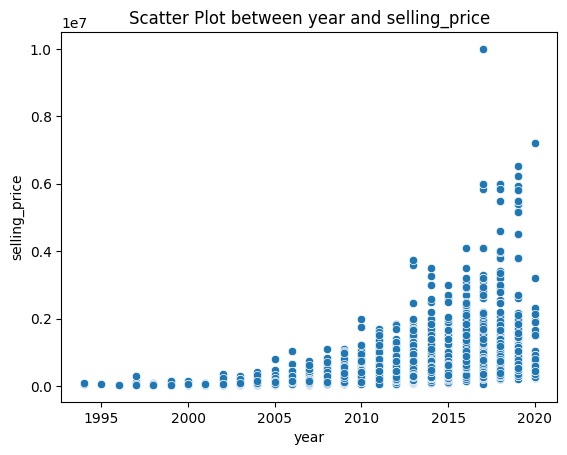

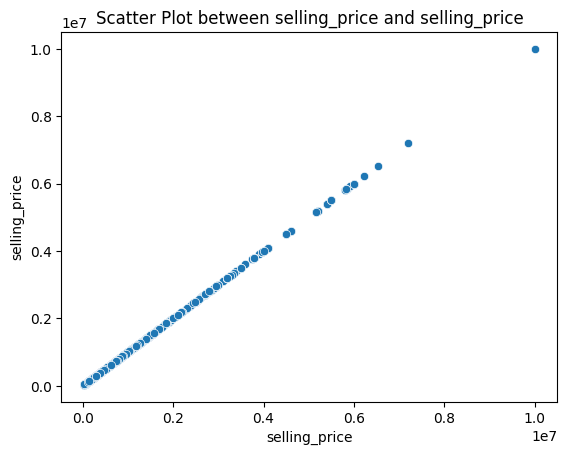

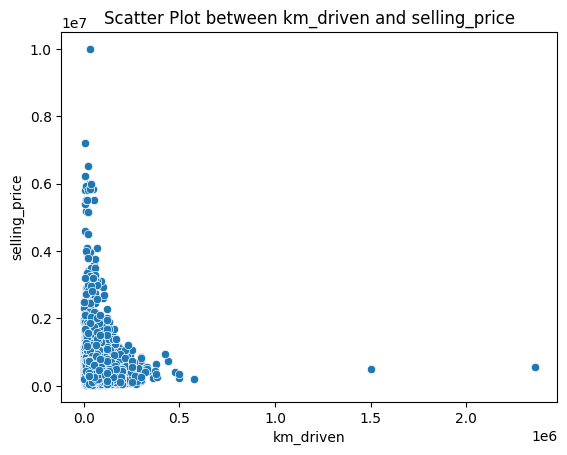

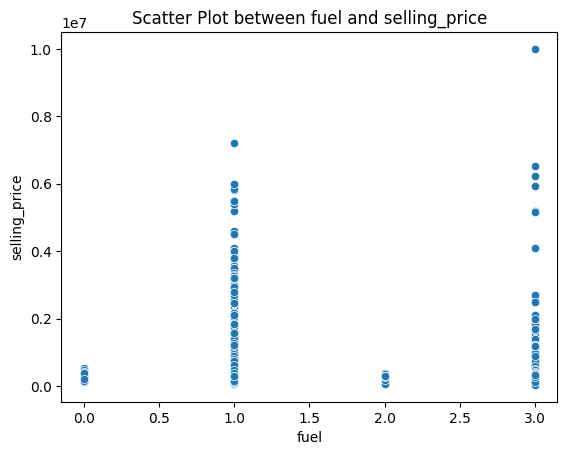

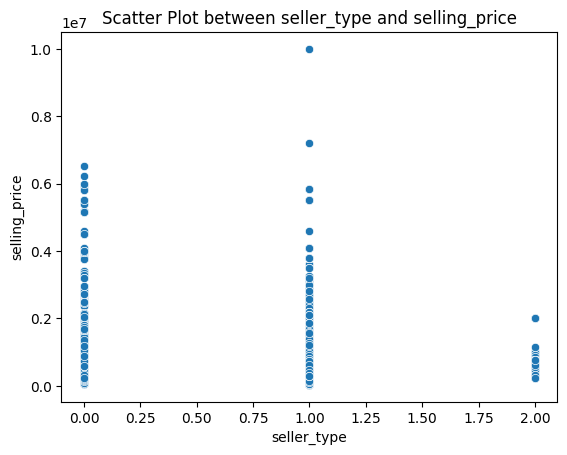

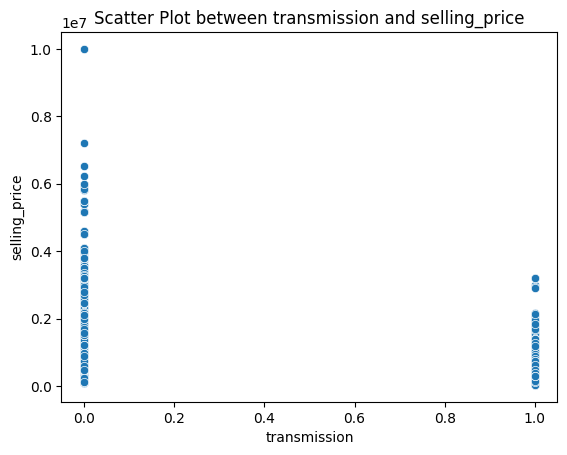

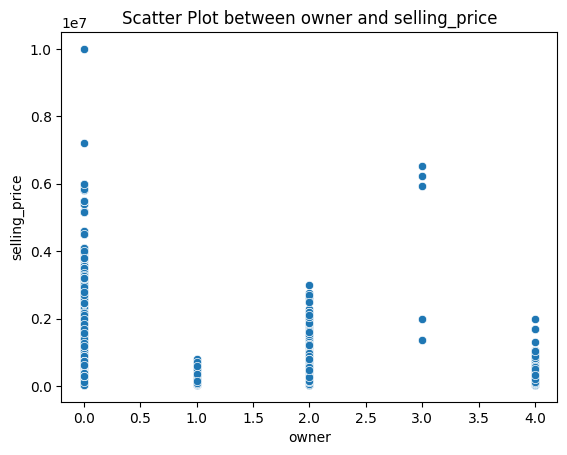

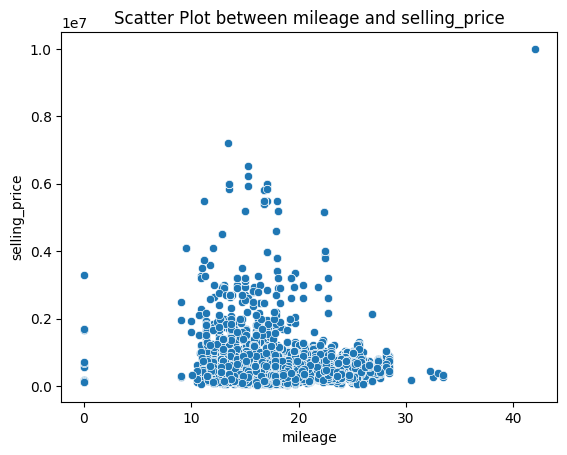

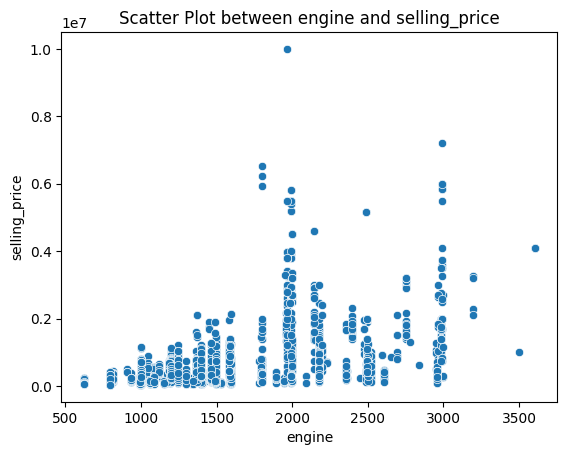

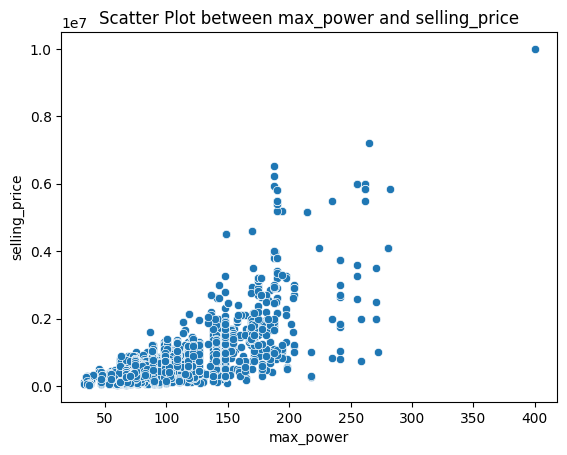

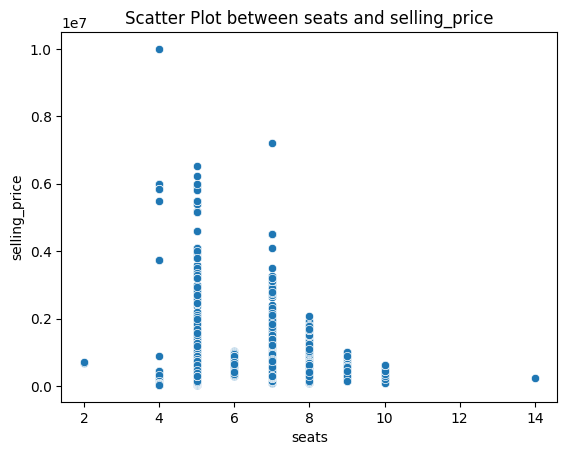

In [61]:
for column in data.columns:
  sns.scatterplot(data=data,x=column,y='selling_price')
  plt.title(f"Scatter Plot between {column} and selling_price")
  plt.show()

**Split the Data**

In [62]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=100)

print(f"size train  : {x_train.shape}    -> y:  {y_train.shape}")
print(f"size test   : {x_test.shape}    -> y:  {y_test.shape}")


size train  : (5534, 10)    -> y:  (5534, 1)
size test   : (2372, 10)    -> y:  (2372, 1)


In [63]:
def rmse(pred,test):
  return np.sqrt(((pred-test)**2).mean())

**Random Forest Regression**

In [72]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,max_error,mean_squared_error

rf=RandomForestRegressor(n_estimators=10,random_state=45)
rf.fit(x_train,y_train)

y_pred_rf=rf.predict(x_test)

#Calculating various scores/metrics

rmse_rf = rmse(y_test,y_pred_rf)
r2_score_rf = r2_score(y_test, y_pred_rf)
max_error_rf = max_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test,y_pred_rf)

print(f"rmse : {rmse_rf}")
print(f"r2_score : {r2_score_rf}")
print(f"max_error : {max_error_rf}")
print(f"mean_squared_error : {mse_rf}")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



rmse : 0.1153436609209096
r2_score : 0.9643175951663631
max_error : 0.27382143692864214
mean_squared_error : 0.00024105935329161087
